In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df_train = pd.read_csv("/kaggle/input/titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
data_train = df_train.copy()
data_test = df_test.copy()

In [4]:
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
data_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


<AxesSubplot:>

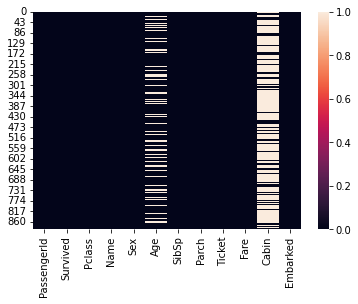

In [9]:
sns.heatmap(data_train.isna())

In [10]:
data_train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
data_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
data_train.drop(['Cabin', 'Ticket'], axis=1, inplace=True)

In [13]:
data_test.drop(['Cabin', 'Ticket'], axis=1, inplace=True)

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

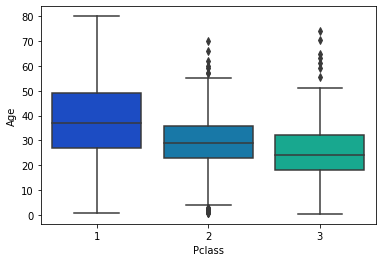

In [14]:
sns.boxplot(x="Pclass", y="Age", data=data_train, palette="winter")

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

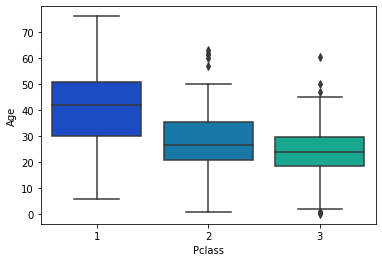

In [15]:
sns.boxplot(x="Pclass", y="Age", data=data_test,palette="winter")

In [16]:
def fill_age(col):
    Age = col[0]
    Pclass = col[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [17]:
data_train["Age"] = data_train[['Age', 'Pclass']].apply(fill_age, axis=1)
data_test["Age"] = data_test[['Age', 'Pclass']].apply(fill_age, axis=1)

<AxesSubplot:>

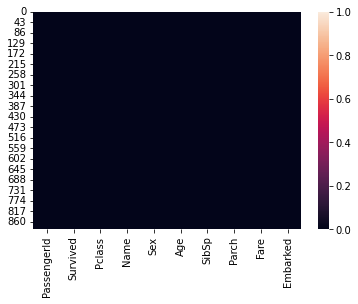

In [18]:
sns.heatmap(data_train.isna())

<AxesSubplot:>

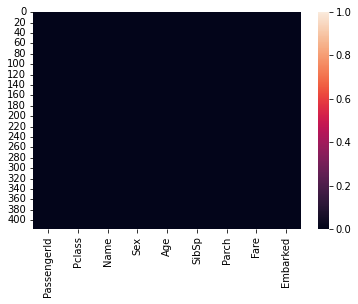

In [19]:
sns.heatmap(data_test.isna())

# Data Exploring 

<AxesSubplot:xlabel='Survived', ylabel='count'>

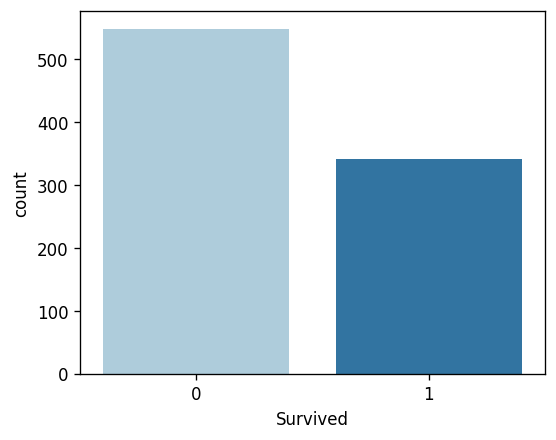

In [20]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(x=data_train['Survived'], palette="Paired")

Only 40.5% of people are survived

Text(0.5, 1.0, '# of people for each class')

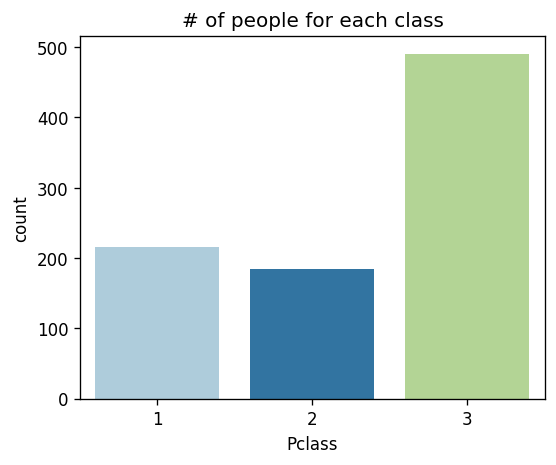

In [21]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x='Pclass', palette="Paired")
plt.title('# of people for each class')

Most of passengers in the 3th class. Let's examine the percentages of passengers that survived ,depending on their port of class.



Text(0.5, 1.0, '# of servived people for each class')

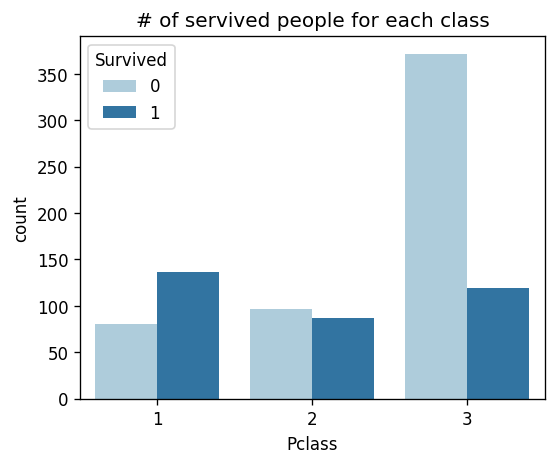

In [22]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x='Pclass', hue="Survived",palette="Paired")
plt.title("# of servived people for each class")

Most of people aren't survived in the 3th class while most of people in class 1th are survived.

Text(0.5, 1.0, 'Pclass vs Fare')

<Figure size 720x480 with 0 Axes>

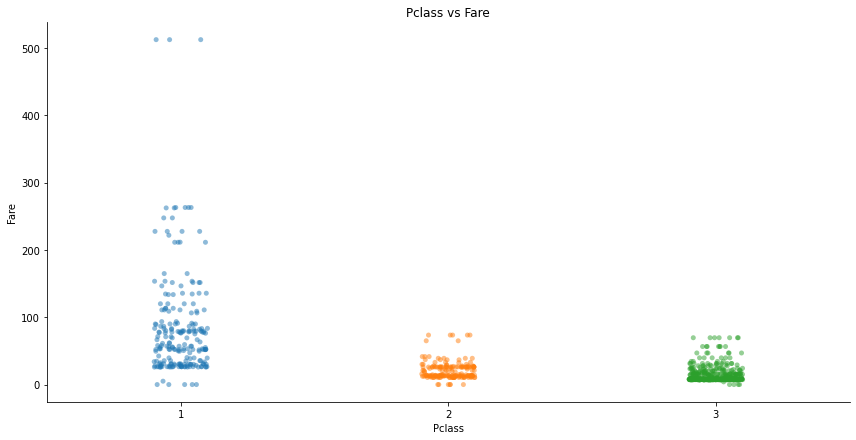

In [23]:
plt.figure(dpi=120)
sns.catplot(data=data_train, x="Pclass", y="Fare", alpha=0.5,aspect=2, height=6)
plt.title("Pclass vs Fare")

1th class has is the expensive one so perhaps this class has more safety measures.

Text(0.5, 1.0, 'Sex')

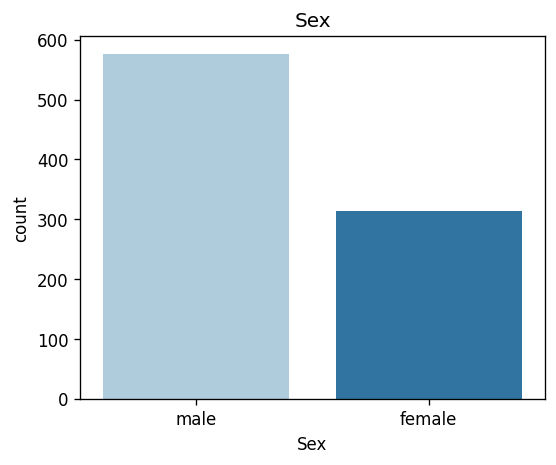

In [24]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x='Sex', palette="Paired")
plt.title("Sex")

Text(0.5, 1.0, '# of survived for each type of Sex')

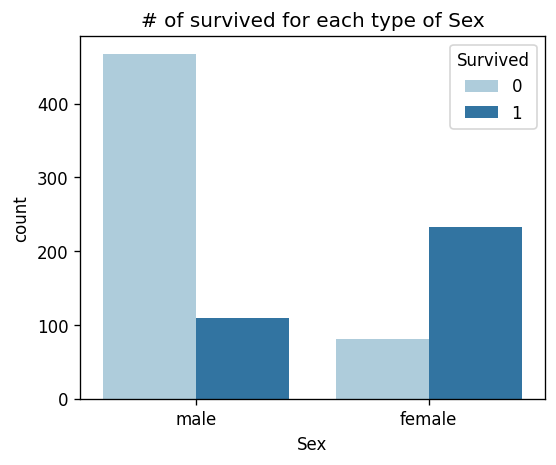

In [25]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x="Sex", hue='Survived', palette="Paired")
plt.title("# of survived for each type of Sex")

Most of women are survived and most of men are not survived  

Text(0.5, 1.0, 'Age distribution')

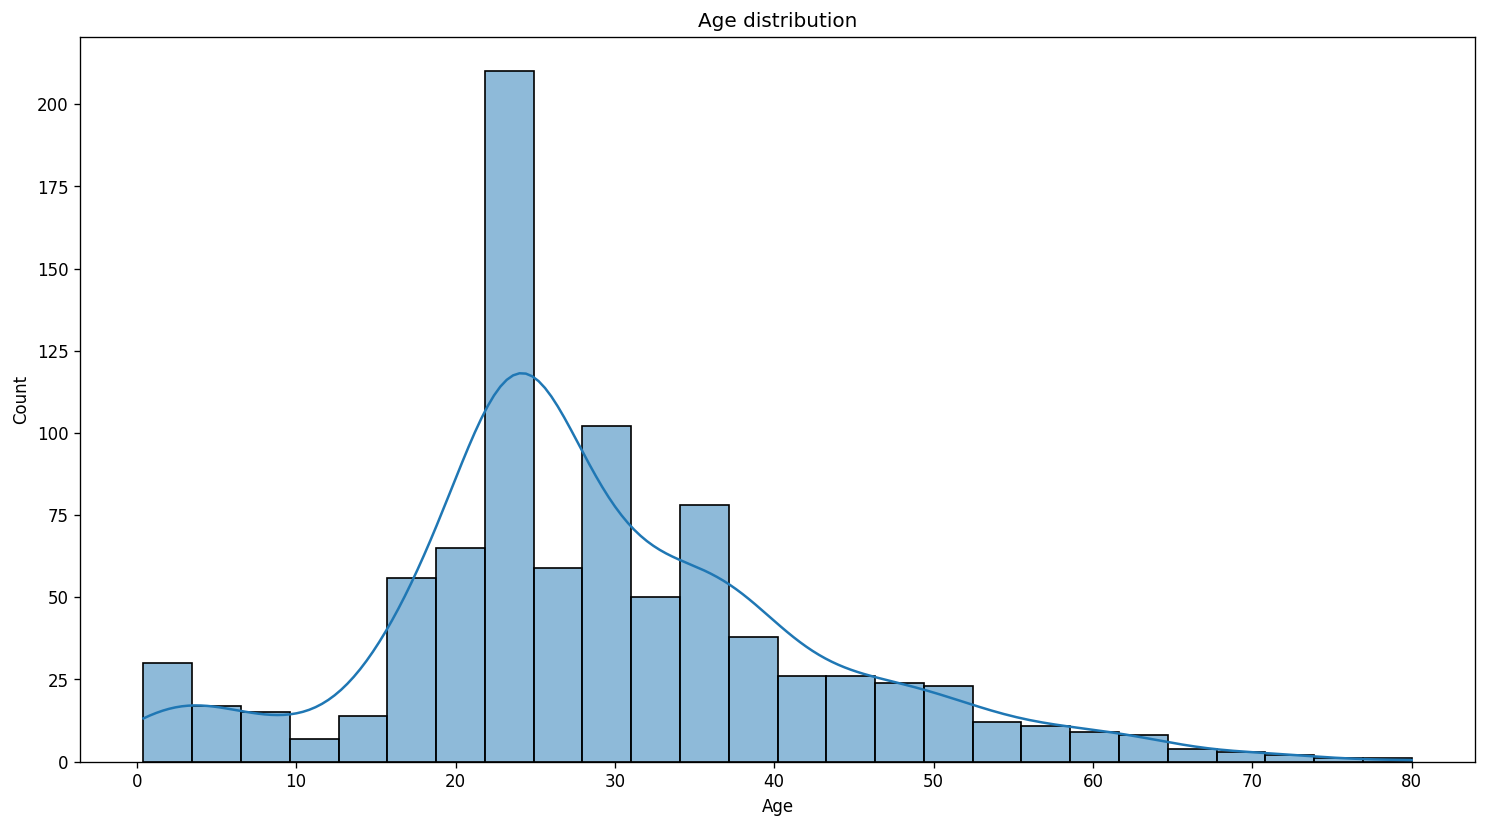

In [26]:
plt.figure(figsize=(15,8), dpi=120)
sns.histplot(x=data_train["Age"], kde=True)
plt.title("Age distribution")

<AxesSubplot:xlabel='Age', ylabel='Count'>

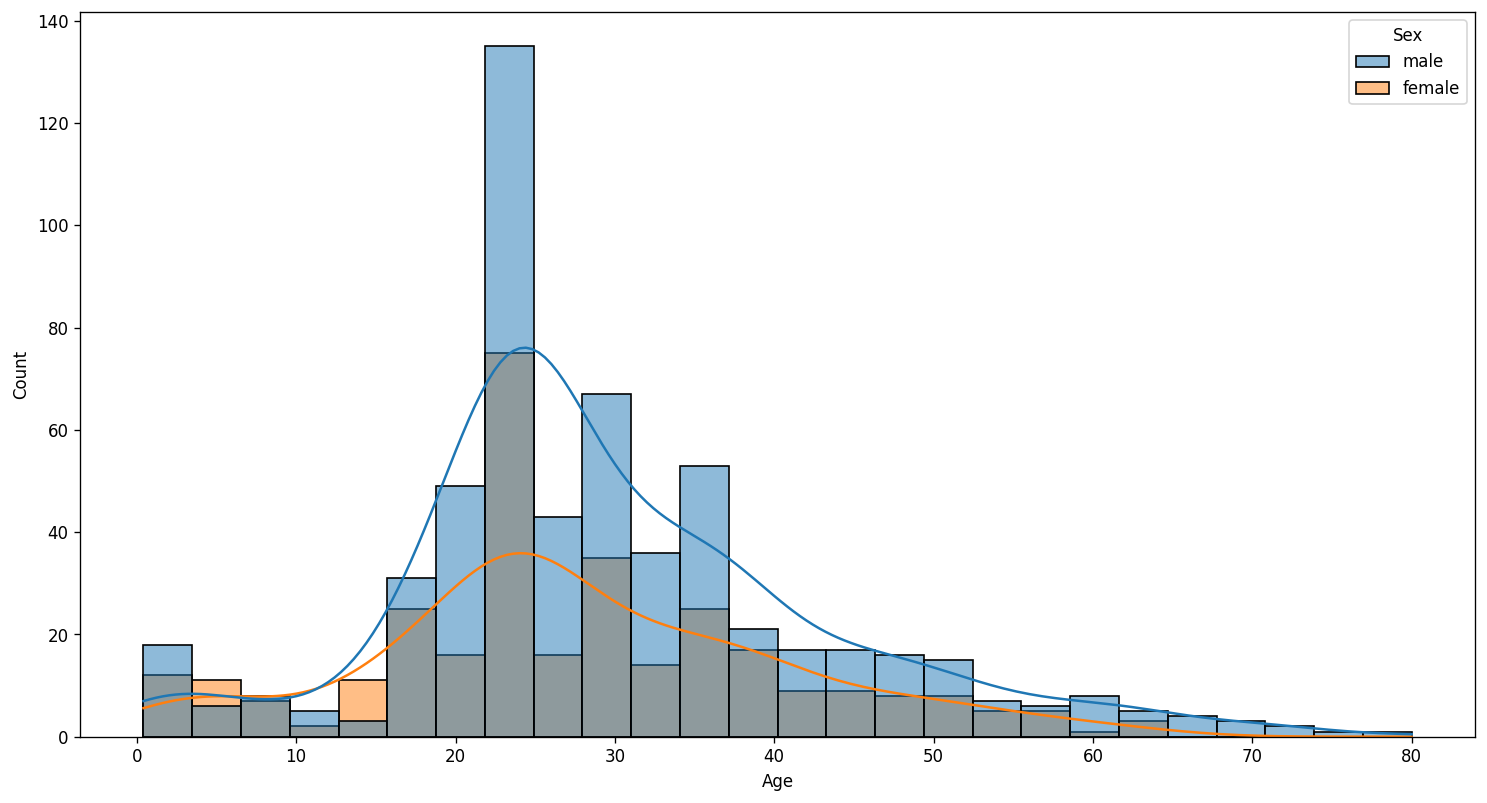

In [27]:
plt.figure(figsize=(15,8), dpi=120)
sns.histplot(x=data_train["Age"], hue=data_train["Sex"], kde=True)


-# of men in all age more than women, Because the total of men more than women

<AxesSubplot:xlabel='Age', ylabel='Count'>

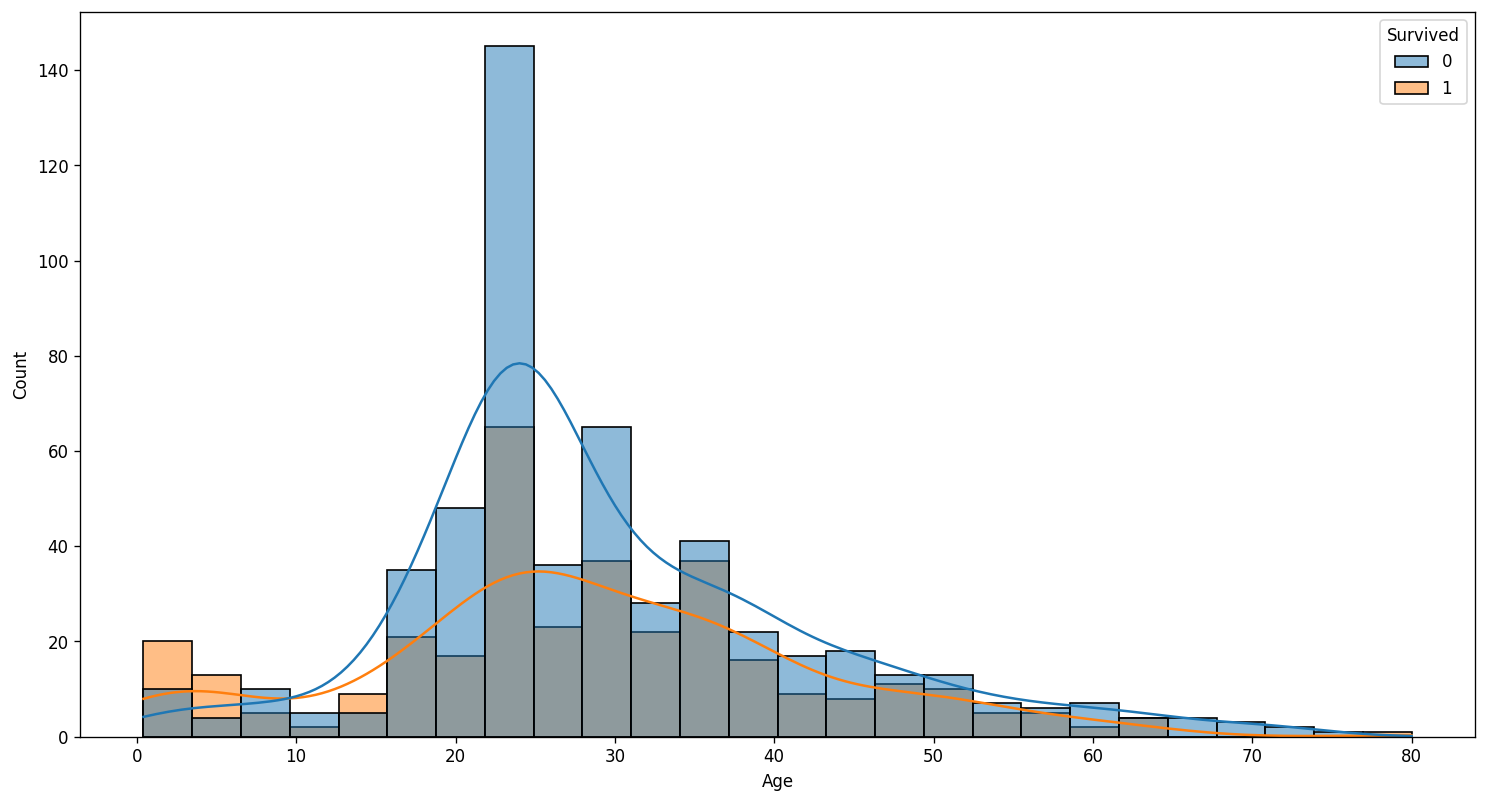

In [28]:
plt.figure(figsize=(15,8), dpi=120)
sns.histplot(x=data_train["Age"], hue=data_train["Survived"], kde=True)


Children and oldest people have a chance to survive more than other 

Text(0.5, 1.0, 'Sex vs Age')

<Figure size 1800x1200 with 0 Axes>

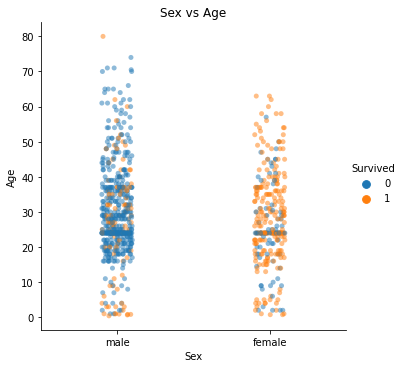

In [29]:
plt.figure(figsize=(15,10), dpi=120)
sns.catplot(data=data_train, x="Sex", y="Age",hue="Survived", alpha=0.5)
plt.title("Sex vs Age")

Women have a chance to survive more than men

<AxesSubplot:xlabel='Embarked', ylabel='count'>

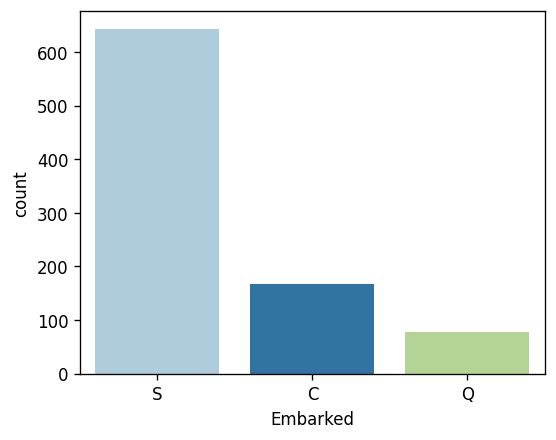

In [30]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x='Embarked',palette="Paired")

Text(0.5, 1.0, '# of survived for each type of Sex')

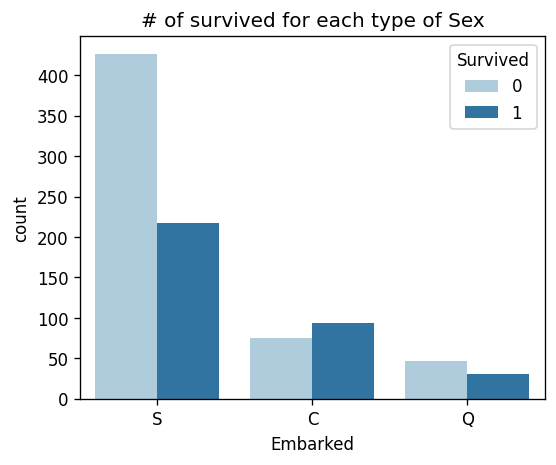

In [31]:
plt.figure(figsize=(5,4), dpi=120)
sns.countplot(data=data_train, x="Embarked", hue='Survived', palette="Paired")
plt.title("# of survived for each type of Sex")

Most survived from Cherbourg bescause most of people from Cherbourg 

In [32]:
gender_le = LabelEncoder()
embarked_le = LabelEncoder()
data_train['Sex'] = gender_le.fit_transform(data_train['Sex'])
data_train['Embarked'] = embarked_le.fit_transform(data_train['Embarked'])

<AxesSubplot:>

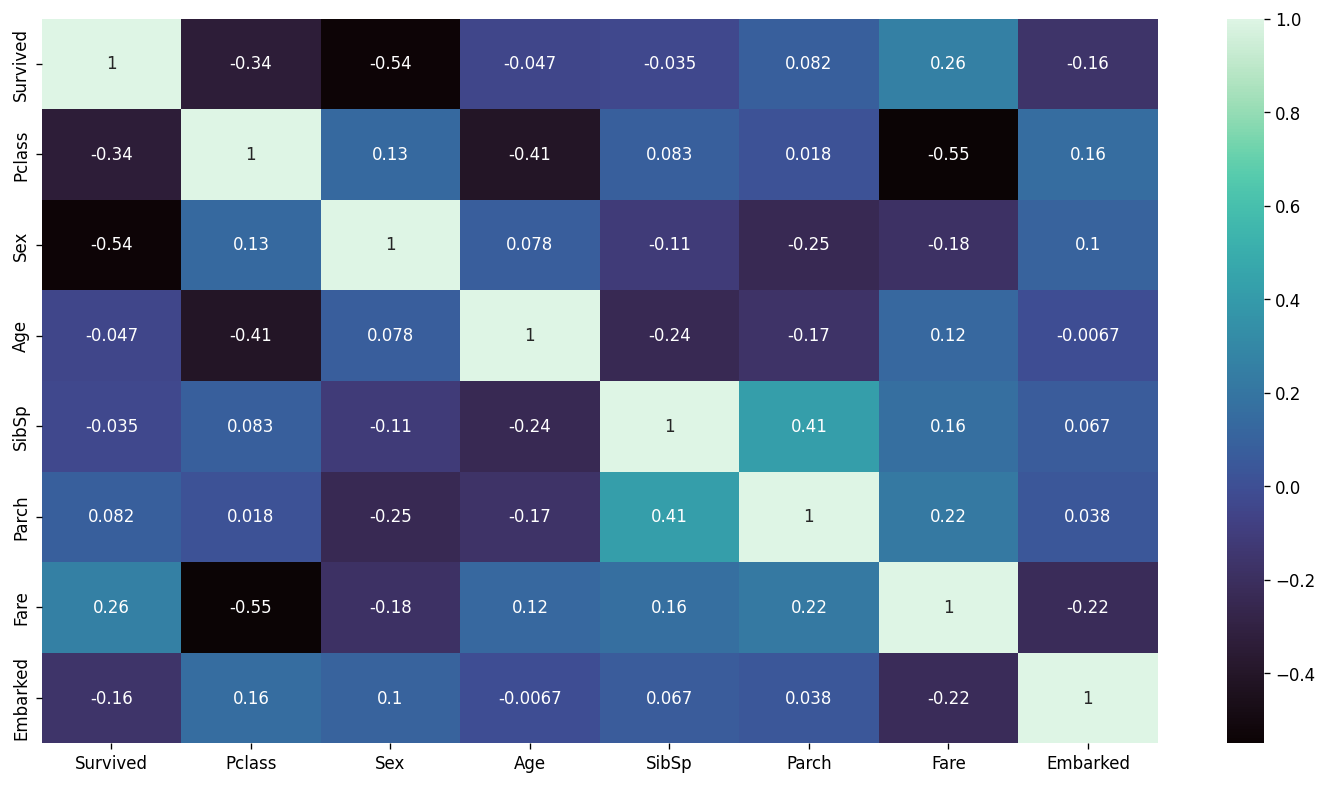

In [33]:
plt.figure(figsize=(15,8), dpi=120)
sns.heatmap(data_train.drop('PassengerId', axis=1).corr(), annot=True,cmap="mako")

Survived column has a strong negative relation with sex and Pclass column 

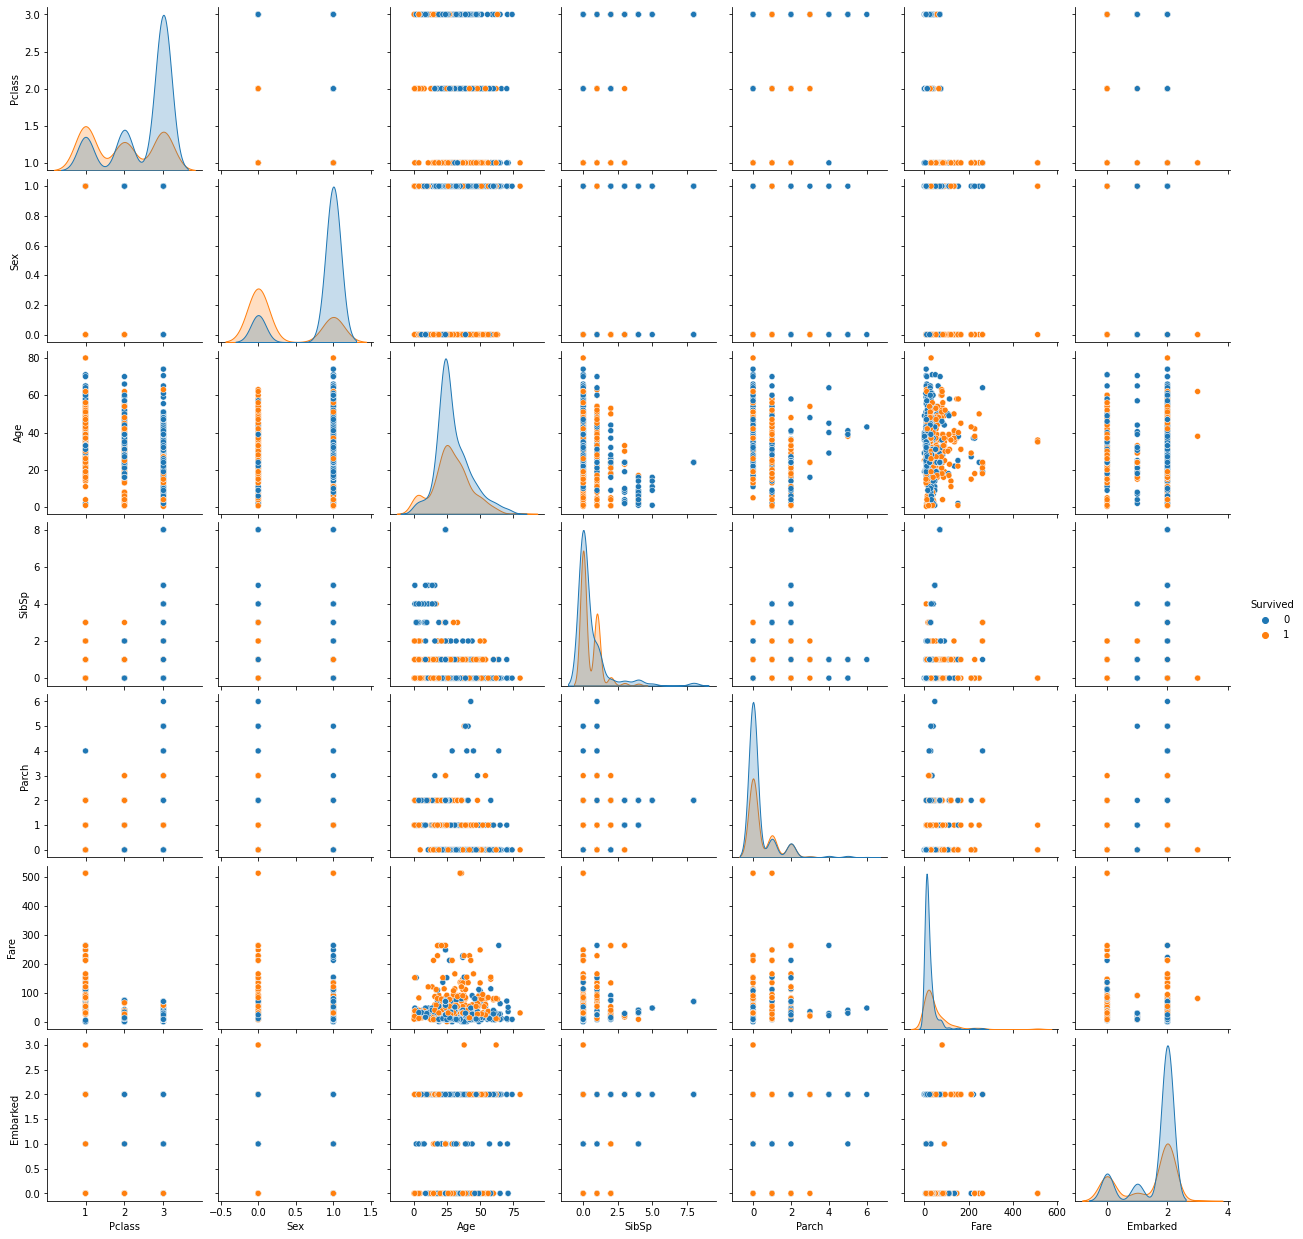

In [34]:
sns.pairplot(data_train.drop(['PassengerId'],axis=1), hue='Survived')

# Build Model

In [35]:
X = data_train.drop(['PassengerId', 'Name', 'Survived', 'Fare','Parch'], axis=True).values
y = data_train['Survived'].values

In [36]:
sm = SMOTE(random_state=40)
X, y = sm.fit_resample(X, y)

In [37]:
rob_scaler = RobustScaler()
X = rob_scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.25, random_state=42)

## RandomForestClassifier

In [38]:
clssif = RandomForestClassifier(random_state=5, max_depth= 11, min_samples_split= 16, n_estimators= 60)

In [39]:
clssif.fit(X_train, y_train)

RandomForestClassifier(max_depth=11, min_samples_split=16, n_estimators=60,
                       random_state=5)

In [40]:
clssif.score(X_train, y_train)

0.8784933171324423

In [41]:
clssif.score(X_test, y_test)

0.850909090909091

In [42]:
train_pred = clssif.predict(X_train)

In [43]:
confusion_matrix(y_train, train_pred)

array([[380,  35],
       [ 65, 343]])

In [44]:
test_pred = clssif.predict(X_test)

In [45]:
confusion_matrix(y_test, test_pred)

array([[120,  14],
       [ 27, 114]])